<a href="https://colab.research.google.com/github/AIVIETNAM-AIO-CongNguyen/CV-system-/blob/qa-testing-docs/resume_extraction_upgraded.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 🤖 10. LLM-based Resume Parsing (Thay thế Regex + spaCy)

In [ ]:
import json
import os
import re
import anthropic

# API Key (thay bằng key thực của bạn) (moved from Enz23y4wZgkV)
ANTHROPIC_API_KEY = os.environ.get('ANTHROPIC_API_KEY', 'your-api-key-here')

class LLMResumeParser:
    """
    Parser nâng cấp dùng Claude API.
    Thay thế Regex + spaCy pattern matching.
    """

    EXTRACTION_PROMPT = """Extract structured information from the resume below.
Return ONLY a valid JSON object with these fields (use null if not found):
{
  "name": "Full name",
  "email": "email@example.com",
  "phone": "phone number",
  "location": "City, Country",
  "summary": "Professional summary (2-3 sentences)",
  "skills": ["skill1", "skill2"],
  "experience_years": 5,
  "education": [{"degree": "BS", "field": "CS", "institution": "MIT", "year": 2020}],
  "work_experience": [{"company": "Google", "role": "Engineer", "duration": "2020-2023"}],
  "certifications": ["cert1"],
  "languages": ["English", "Vietnamese"]
}

RESUME:
"""

    def __init__(self, api_key):
        self.client = anthropic.Anthropic(api_key=api_key)

    def parse(self, resume_text, max_chars=4000):
        """Parse một resume, trả về dict có cấu trúc."""
        # Cắt bớt nếu quá dài
        text = resume_text[:max_chars]

        try:
            response = self.client.messages.create(
                model='claude-sonnet-4-6',
                max_tokens=1500,
                messages=[{
                    'role': 'user',
                    'content': self.EXTRACTION_PROMPT + text
                }]
            )
            raw = response.content[0].text.strip()
            # Clean JSON
            raw = re.sub(r'^```json\s*|```\s*$', '', raw).strip()
            return json.loads(raw)
        except json.JSONDecodeError as e:
            return {'error': f'JSON parse failed: {str(e)}', 'raw': raw}
        except Exception as e:
            return {'error': str(e)}

    def batch_parse(self, resume_texts, show_progress=True):
        """Parse nhiều resume."""
        results = []
        for i, text in enumerate(resume_texts):
            if show_progress and (i+1) % 10 == 0:
                print(f'  Parsed {i+1}/{len(resume_texts)}')
            results.append(self.parse(text))
        return results


# Demo (cần API key)
if ANTHROPIC_API_KEY != 'your-api-key-here':
    parser = LLMResumeParser(ANTHROPIC_API_KEY)
    sample_resume = df['Resume'].iloc[0]
    print('Parsing resume with Claude API...')
    parsed = parser.parse(sample_resume)
    print('\n Extracted Information:')
    for key, value in parsed.items():
        if value:
            print(f'  {key}: {value}')
else:
    print(' Set ANTHROPIC_API_KEY to test LLM parsing.')
    print('   Demo output would look like:')
    demo_output = {
        'name': 'John Doe', 'email': 'john@email.com',
        'skills': ['Python', 'Machine Learning', 'TensorFlow'],
        'experience_years': 5, 'education': [{'degree': 'MS', 'field': 'Data Science'}]
    }
    print(json.dumps(demo_output, indent=2))

⚠️  Set ANTHROPIC_API_KEY to test LLM parsing.
   Demo output would look like:
{
  "name": "John Doe",
  "email": "john@email.com",
  "skills": [
    "Python",
    "Machine Learning",
    "TensorFlow"
  ],
  "experience_years": 5,
  "education": [
    {
      "degree": "MS",
      "field": "Data Science"
    }
  ]
}


## 📏 11. Error Evaluation Framework cho Simple Chatbot

**Đánh giá chất lượng response của chatbot tư vấn nghề nghiệp đi kèm hệ thống.**

In [ ]:
class ChatbotEvaluator:
    """
    Đánh giá chatbot response với đầy đủ metrics:
    - BLEU: n-gram precision
    - ROUGE-1/2/L: recall-oriented
    - BERTScore: semantic similarity
    - Cosine Similarity: embedding-level
    """

    def __init__(self, sbert_model_name=SBERT_MODEL):
        self.rouge = rouge_scorer.RougeScorer(
            ['rouge1', 'rouge2', 'rougeL'], use_stemmer=True
        )
        self.sbert = SentenceTransformer(sbert_model_name)
        self.smoothing = SmoothingFunction().method1

    def compute_bleu(self, reference, hypothesis):
        """BLEU score (0-1, higher is better)."""
        ref_tokens = reference.lower().split()
        hyp_tokens = hypothesis.lower().split()
        return sentence_bleu(
            [ref_tokens], hyp_tokens,
            smoothing_function=self.smoothing
        )

    def compute_rouge(self, reference, hypothesis):
        """ROUGE scores."""
        scores = self.rouge.score(reference, hypothesis)
        return {
            'rouge1': round(scores['rouge1'].fmeasure, 4),
            'rouge2': round(scores['rouge2'].fmeasure, 4),
            'rougeL': round(scores['rougeL'].fmeasure, 4),
        }

    def compute_bertscore(self, references, hypotheses, lang='en'):
        """BERTScore (batch)."""
        P, R, F1 = bert_score(
            hypotheses, references,
            lang=lang, verbose=False
        )
        return {
            'bertscore_precision': round(P.mean().item(), 4),
            'bertscore_recall':    round(R.mean().item(), 4),
            'bertscore_f1':        round(F1.mean().item(), 4),
        }

    def compute_cosine(self, reference, hypothesis):
        """Semantic cosine similarity."""
        embs = self.sbert.encode([reference, hypothesis], convert_to_tensor=True)
        return round(float(util.cos_sim(embs[0], embs[1])), 4)

    def evaluate(self, references, hypotheses):
        """
        Đánh giá toàn diện một tập examples.

        Args:
            references:  List[str] - ground truth responses
            hypotheses:  List[str] - chatbot responses

        Returns: DataFrame với tất cả metrics
        """
        assert len(references) == len(hypotheses), 'Length mismatch!'

        rows = []
        for ref, hyp in zip(references, hypotheses):
            row = {
                'reference': ref[:100] + '...' if len(ref) > 100 else ref,
                'hypothesis': hyp[:100] + '...' if len(hyp) > 100 else hyp,
                'bleu': round(self.compute_bleu(ref, hyp), 4),
                'cosine_similarity': self.compute_cosine(ref, hyp),
            }
            row.update(self.compute_rouge(ref, hyp))
            rows.append(row)

        df_results = pd.DataFrame(rows)

        # BERTScore (batch)
        bert_scores = self.compute_bertscore(references, hypotheses)
        for k, v in bert_scores.items():
            df_results[k] = v  # Same value for all rows (batch average)

        return df_results

    def summary(self, eval_df):
        """In bảng tổng kết metrics."""
        metric_cols = ['bleu', 'rouge1', 'rouge2', 'rougeL',
                       'cosine_similarity', 'bertscore_f1']
        summary = eval_df[metric_cols].agg(['mean', 'std', 'min', 'max']).round(4)
        print('\n📊 Evaluation Summary:')
        print('=' * 60)
        print(summary.to_string())
        return summary


print(' ChatbotEvaluator defined!')

✅ ChatbotEvaluator defined!


In [ ]:
from rouge_score import rouge_scorer
from nltk.translate.bleu_score import SmoothingFunction
from nltk.translate.bleu_score import sentence_bleu
from bert_score import score as bert_score
from sentence_transformers import SentenceTransformer, util # Added

# Configuration (moved from Enz23y4wZgkV and KSo6P7SUZgkT)
SBERT_MODEL = 'all-MiniLM-L6-v2'

# Demo đánh giá với các example pairs
test_pairs = [
    (
        "Your resume shows strong Python and Machine Learning skills. I recommend applying for Data Science roles.",
        "Based on your Python expertise and ML background, Data Scientist positions would be a great fit."
    ),
    (
        "You have 5 years of Java development experience which qualifies you for senior backend positions.",
        "With extensive Java experience, you qualify for senior software engineer roles."
    ),
    (
        "Your resume lacks cloud experience. Consider getting AWS certification to improve your profile.",
        "The weather today is sunny and warm."
    ),  # Intentionally bad response to show metric difference
]

references  = [p[0] for p in test_pairs]
hypotheses  = [p[1] for p in test_pairs]

print(' Running evaluation...')
evaluator  = ChatbotEvaluator(sbert_model_name=SBERT_MODEL)
eval_df    = evaluator.evaluate(references, hypotheses)
eval_df.to_csv('/tmp/chatbot_eval_results.csv', index=False)

print('\n Per-example Results:')
display_cols = ['bleu', 'rouge1', 'rouge2', 'rougeL', 'cosine_similarity', 'bertscore_f1']
print(eval_df[display_cols].to_string())
evaluator.summary(eval_df)

🔄 Running evaluation...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



📋 Per-example Results:
     bleu  rouge1  rouge2  rougeL  cosine_similarity  bertscore_f1
0  0.0174  0.2500  0.0000  0.2500             0.7123        0.9042
1  0.0330  0.4615  0.0833  0.3846             0.8110        0.9042
2  0.0000  0.0000  0.0000  0.0000             0.0419        0.9042

📊 Evaluation Summary:
        bleu  rouge1  rouge2  rougeL  cosine_similarity  bertscore_f1
mean  0.0168  0.2372  0.0278  0.2115             0.5217        0.9042
std   0.0165  0.2310  0.0481  0.1952             0.4185        0.0000
min   0.0000  0.0000  0.0000  0.0000             0.0419        0.9042
max   0.0330  0.4615  0.0833  0.3846             0.8110        0.9042


,bleu,rouge1,rouge2,rougeL,cosine_similarity,bertscore_f1
mean,0.0168,0.2372,0.0278,0.2115,0.5217,0.9042
std,0.0165,0.2310,0.0481,0.1952,0.4185,0.0000
min,0.0000,0.0000,0.0000,0.0000,0.0419,0.9042
max,0.0330,0.4615,0.0833,0.3846,0.8110,0.9042


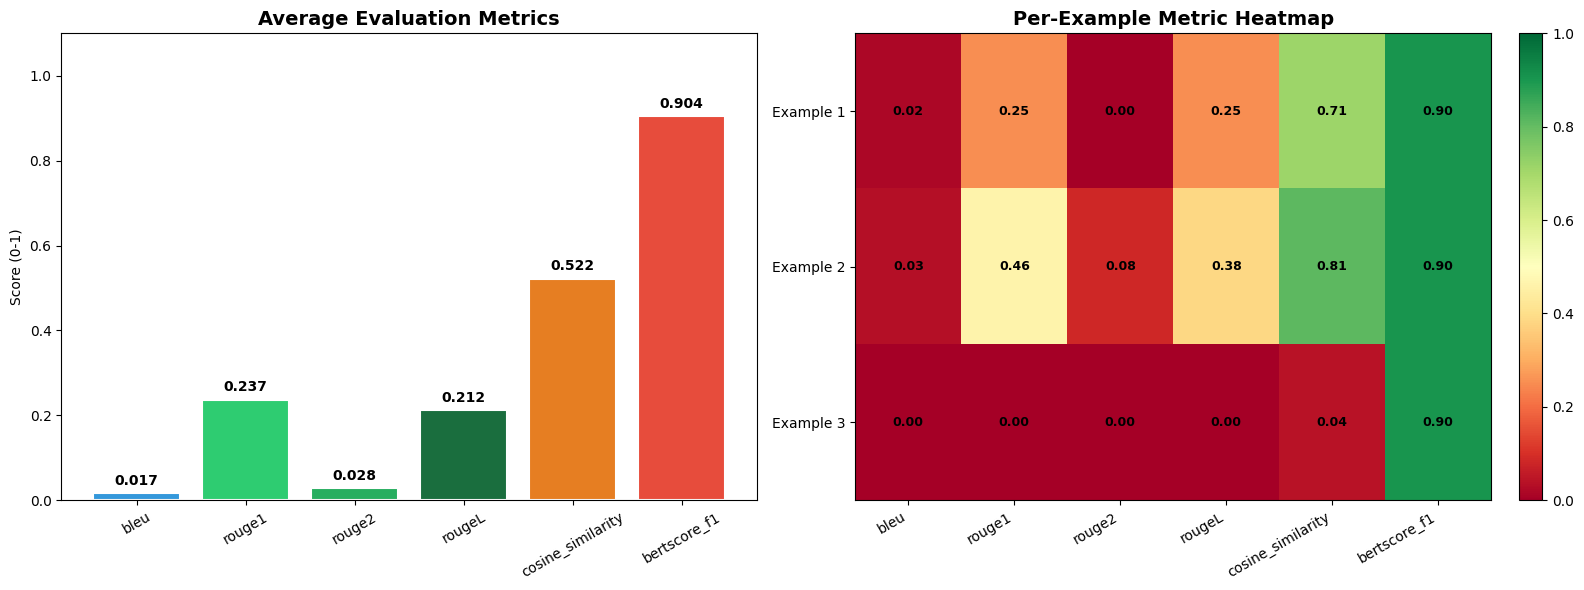

In [ ]:
# Visualize metrics comparison
metric_cols = ['bleu', 'rouge1', 'rouge2', 'rougeL', 'cosine_similarity', 'bertscore_f1']
means = eval_df[metric_cols].mean()

colors = ['#3498db', '#2ecc71', '#27ae60', '#1a6e3e', '#e67e22', '#e74c3c']
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Average metrics bar
bars = axes[0].bar(metric_cols, means.values, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Average Evaluation Metrics', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Score (0-1)')
axes[0].set_ylim(0, 1.1)
axes[0].tick_params(axis='x', rotation=30)
for bar, val in zip(bars, means.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{val:.3f}', ha='center', fontweight='bold')

# Per-example heatmap
heat_data = eval_df[metric_cols].values
im = axes[1].imshow(heat_data, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
axes[1].set_xticks(range(len(metric_cols)))
axes[1].set_xticklabels(metric_cols, rotation=30, ha='right')
axes[1].set_yticks(range(len(eval_df)))
axes[1].set_yticklabels([f'Example {i+1}' for i in range(len(eval_df))])
axes[1].set_title('Per-Example Metric Heatmap', fontsize=14, fontweight='bold')
plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
for i in range(len(eval_df)):
    for j in range(len(metric_cols)):
        axes[1].text(j, i, f'{heat_data[i,j]:.2f}', ha='center', va='center',
                     fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()